## Tarea M22-CD - YAIR PALOMARES

In [37]:
import pandas as pd
import pylab as pl
import numpy as np
import scipy.optimize as opt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import os
os.chdir("C:/Users/yair_/OneDrive/Desktop/Ciencia de Datos/Módulo 21 - KNN y métricas de clasificación")

In [38]:
data = pd.read_csv("recursos_humanos.csv")
data

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [39]:
#Normalización de columnas faltantes
data["average_montly_hours"] = (data["average_montly_hours"] - np.min(data["average_montly_hours"])) / (np.max(data["average_montly_hours"]) - np.min(data["average_montly_hours"]))
data["time_spend_company"] = (data["time_spend_company"] - np.min(data["time_spend_company"])) / (np.max(data["time_spend_company"]) - np.min(data["time_spend_company"]))

#Se crean las variables dummy para las variables categóricas
number_project_dummy = pd.get_dummies(data["number_project"], prefix="Project", dtype= np.uint8)
number_sales_dummy = pd.get_dummies(data["sales"], prefix="Sales", dtype = np.uint8)
number_salary_dummy = pd.get_dummies(data["salary"], prefix="Salary", dtype = np.uint8)

#Se concatenan las columnas de las variables dummy creadas
data = pd.concat([data, number_project_dummy], axis=1)
data = pd.concat([data, number_sales_dummy], axis=1)
data = pd.concat([data, number_salary_dummy], axis=1)
data

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary,...,Sales_hr,Sales_management,Sales_marketing,Sales_product_mng,Sales_sales,Sales_support,Sales_technical,Salary_high,Salary_low,Salary_medium
0,0.38,0.53,2,0.285047,0.125,0,1,0,sales,low,...,0,0,0,0,1,0,0,0,1,0
1,0.80,0.86,5,0.775701,0.500,0,1,0,sales,medium,...,0,0,0,0,1,0,0,0,0,1
2,0.11,0.88,7,0.822430,0.250,0,1,0,sales,medium,...,0,0,0,0,1,0,0,0,0,1
3,0.72,0.87,5,0.593458,0.375,0,1,0,sales,low,...,0,0,0,0,1,0,0,0,1,0
4,0.37,0.52,2,0.294393,0.125,0,1,0,sales,low,...,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,0.257009,0.125,0,1,0,support,low,...,0,0,0,0,0,1,0,0,1,0
14995,0.37,0.48,2,0.299065,0.125,0,1,0,support,low,...,0,0,0,0,0,1,0,0,1,0
14996,0.37,0.53,2,0.219626,0.125,0,1,0,support,low,...,0,0,0,0,0,1,0,0,1,0
14997,0.11,0.96,6,0.859813,0.250,0,1,0,support,low,...,0,0,0,0,0,1,0,0,1,0


<function matplotlib.pyplot.show(close=None, block=None)>

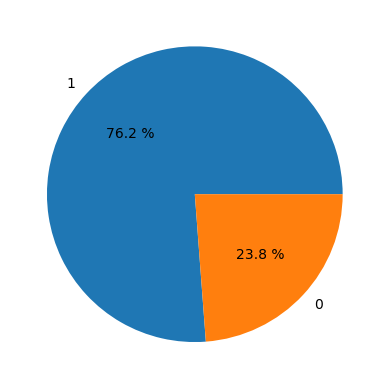

In [40]:
#Análisis exploratorio de los datos para validar equilibrio
frec_left = pd.value_counts(data["left"])
etiquetas = list(data['left'].unique())
plt.pie(frec_left, labels=etiquetas , autopct="%0.1f %%")
plt.show

In [41]:
#Se eliminan las columnas de las variables categóricas
data.drop(["number_project", "sales", "salary"], axis=1, inplace=True)

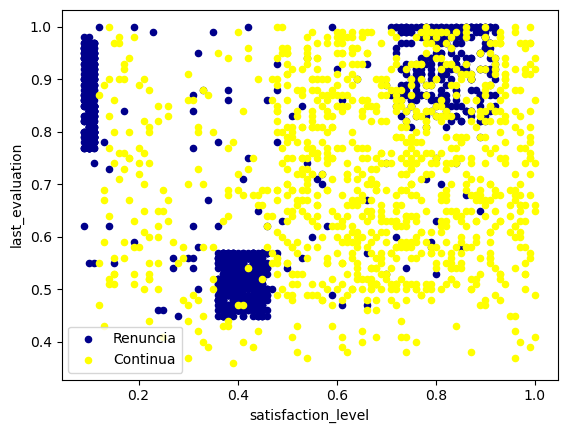

In [42]:
#Análisis exploratorio
ax = data[data["left"] == 1][0:1000].plot(kind="scatter", x="satisfaction_level", y="last_evaluation", color="DarkBlue", label="Renuncia")
ax = data[data["left"] == 0][0:1000].plot(kind="scatter", x="satisfaction_level", y="last_evaluation", color="Yellow", label="Continua", ax=ax)
plt.show()

In [43]:
#Se definen variables dependientes e independientes
y = data.left.values
x = data.drop(["left"], axis=1)

#Base de entrenamiento y prueba
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3, random_state=1)

## Modelación con SVM

#### Modelo Lineal

In [44]:
from sklearn import svm
clf = svm.SVC(kernel="linear")
clf.fit(x_train, y_train)

#Predicción para la base de prueba
y_hat = clf.predict(x_test)

#Creación de matriz de confusión
from sklearn.metrics import confusion_matrix
y_pred = clf.predict(x) #Realiza las predicciones
cm = confusion_matrix(y_test, y_hat)
cm

array([[3123,  293],
       [ 401,  683]], dtype=int64)

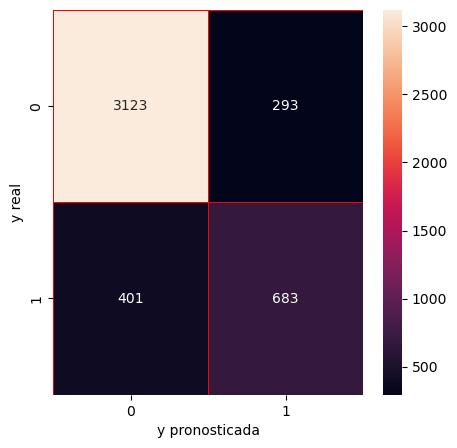

In [45]:
#Visualización de la matriz de confusión
import seaborn as sns
f, ax = plt.subplots(figsize=(5,5))

sns.heatmap(cm, annot=True, linewidths=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y pronosticada")
plt.ylabel("y real")
plt.show()

In [46]:
from sklearn.metrics import classification_report
cnf_matrix = confusion_matrix(y_test, y_hat, labels=[0,1])
print(classification_report(y_test, y_hat))

              precision    recall  f1-score   support

           0       0.89      0.91      0.90      3416
           1       0.70      0.63      0.66      1084

    accuracy                           0.85      4500
   macro avg       0.79      0.77      0.78      4500
weighted avg       0.84      0.85      0.84      4500



##### A través del indicador de precisión, nos percatamos de que la aplicación del modelo lineal del algoritmo SVM permite predecir correctamente un 89% de los casos donde el trabajador decide no renunciar, mientras que es capaz de predecir correctamente en un 70% de las ocasiones los casos donde el trabajador toma la decisión de renunciar. Por otro lado, tomando como referencia el valor del indicador recall, del total de casos donde el trabajador no renunció, en el 91% de las ocasiones el algoritmo logró obtener el mismo resultado, mientras que para los casos donde el trabajador renuncia fue capaz de coincidir en un 63% de las ocasiones.
##### Con base en los dos indicadores anteriormente descritos, se obtuvo una evaluación del modelo de 90% para los casos de "No Renunciar", esto de acuerdo al indicador F1-score. Y un 66% de evaluación para los casos de "Renuncia".

#### Modelo Polynomial

In [47]:
#Modelo polynomial
clf = svm.SVC(kernel="poly")
clf.fit(x_train, y_train)

#Predicción para la base de prueba
y_hat = clf.predict(x_test)

#Creación de matriz de confusión
y_pred = clf.predict(x)
cm = confusion_matrix(y_test, y_hat)
cm

array([[3286,  130],
       [ 118,  966]], dtype=int64)

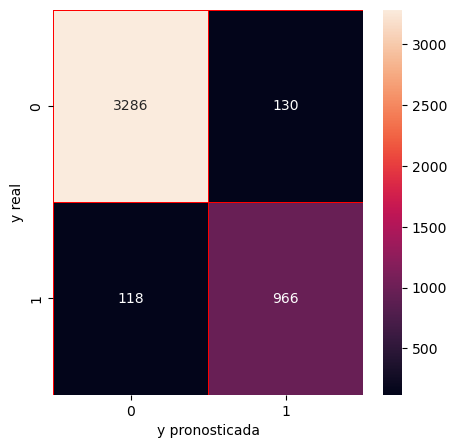

In [48]:
#Visualización de la matriz de confusión
f, ax = plt.subplots(figsize=(5,5))

sns.heatmap(cm, annot=True, linewidths=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y pronosticada")
plt.ylabel("y real")
plt.show()

In [49]:
cnf_matrix = confusion_matrix(y_test, y_hat, labels=[0,1])
print(classification_report(y_test, y_hat))

              precision    recall  f1-score   support

           0       0.97      0.96      0.96      3416
           1       0.88      0.89      0.89      1084

    accuracy                           0.94      4500
   macro avg       0.92      0.93      0.92      4500
weighted avg       0.95      0.94      0.94      4500



##### A través del indicador de precisión, nos percatamos de que la aplicación del modelo polinomial del algoritmo SVM permite predecir correctamente un 97% de los casos donde el trabajador decide no renunciar, mientras que es capaz de predecir correctamente en un 88% de las ocasiones los casos donde el trabajador toma la decisión de renunciar. Por otro lado, tomando como referencia el valor del indicador recall, del total de casos donde el trabajador no renunció, en el 96% de las ocasiones el algoritmo logró obtener el mismo resultado, mientras que para los casos donde el trabajador renuncia fue capaz de coincidir en un 89% de las ocasiones.
##### Con base en los dos indicadores anteriormente descritos, se obtuvo una evaluación del modelo de 96% para los casos de "No Renunciar", esto de acuerdo al indicador F1-score. Y un 89% de evaluación para los casos de "Renuncia".

#### Modelo Radial Basis Function (RBF)

In [24]:
#Modelo RBF
clf = svm.SVC(kernel="rbf")
clf.fit(x_train, y_train)

#Predicción para la base de prueba
y_hat = clf.predict(x_test)

#Creación de matriz de confusión
y_pred = clf.predict(x)
cm = confusion_matrix(y_test, y_hat)
cm

array([[3283,  133],
       [ 148,  936]], dtype=int64)

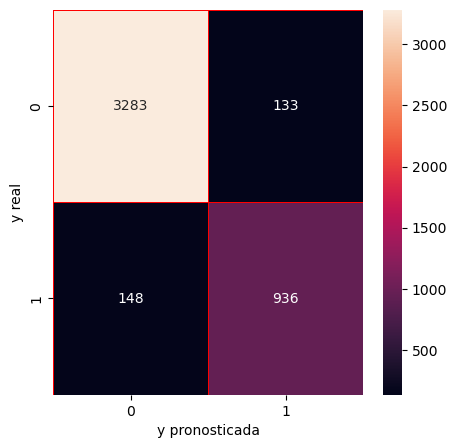

In [25]:
#Visualización de la matriz de confusión
f, ax = plt.subplots(figsize=(5,5))

sns.heatmap(cm, annot=True, linewidths=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y pronosticada")
plt.ylabel("y real")
plt.show()

In [26]:
cnf_matrix = confusion_matrix(y_test, y_hat, labels=[0,1])
print(classification_report(y_test, y_hat))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96      3416
           1       0.88      0.86      0.87      1084

    accuracy                           0.94      4500
   macro avg       0.92      0.91      0.91      4500
weighted avg       0.94      0.94      0.94      4500



##### A través del indicador de precisión, nos percatamos de que la aplicación del modelo RBF del algoritmo SVM permite predecir correctamente un 96% de los casos donde el trabajador decide no renunciar, mientras que es capaz de predecir correctamente en un 88% de las ocasiones los casos donde el trabajador toma la decisión de renunciar. Por otro lado, tomando como referencia el valor del indicador recall, del total de casos donde el trabajador no renunció, en el 96% de las ocasiones el algoritmo logró obtener el mismo resultado, mientras que para los casos donde el trabajador renuncia fue capaz de coincidir en un 86% de las ocasiones.
##### Con base en los dos indicadores anteriormente descritos, se obtuvo una evaluación del modelo de 96% para los casos de "No Renunciar", esto de acuerdo al indicador F1-score. Y un 87% de evaluación para los casos de "Renuncia".

#### Modelo Sigmoid

In [27]:
#Modelo RBF
clf = svm.SVC(kernel="sigmoid")
clf.fit(x_train, y_train)

#Predicción para la base de prueba
y_hat = clf.predict(x_test)

#Creación de matriz de confusión
y_pred = clf.predict(x)
cm = confusion_matrix(y_test, y_hat)
cm

array([[2890,  526],
       [ 566,  518]], dtype=int64)

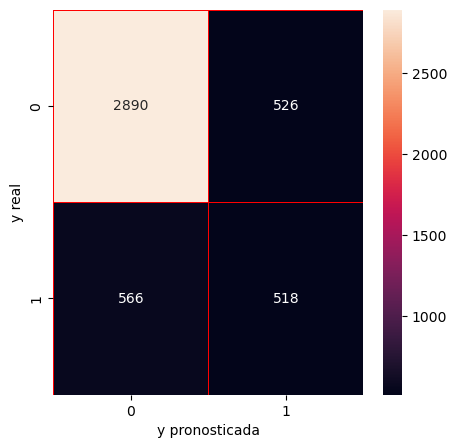

In [28]:
#Visualización de la matriz de confusión
f, ax = plt.subplots(figsize=(5,5))

sns.heatmap(cm, annot=True, linewidths=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y pronosticada")
plt.ylabel("y real")
plt.show()

In [29]:
cnf_matrix = confusion_matrix(y_test, y_hat, labels=[0,1])
print(classification_report(y_test, y_hat))

              precision    recall  f1-score   support

           0       0.84      0.85      0.84      3416
           1       0.50      0.48      0.49      1084

    accuracy                           0.76      4500
   macro avg       0.67      0.66      0.66      4500
weighted avg       0.75      0.76      0.76      4500



##### A través del indicador de precisión, nos percatamos de que la aplicación del modelo sigmoid del algoritmo SVM permite predecir correctamente un 84% de los casos donde el trabajador decide no renunciar, mientras que es capaz de predecir correctamente en un 50% de las ocasiones los casos donde el trabajador toma la decisión de renunciar. Por otro lado, tomando como referencia el valor del indicador recall, del total de casos donde el trabajador no renunció, en el 85% de las ocasiones el algoritmo logró obtener el mismo resultado, mientras que para los casos donde el trabajador renuncia fue capaz de coincidir en un 48% de las ocasiones.
##### Con base en los dos indicadores anteriormente descritos, se obtuvo una evaluación del modelo de 84% para los casos de "No Renunciar", esto de acuerdo al indicador F1-score. Y un 49% de evaluación para los casos de "Renuncia".

In [3]:
#Comparación de modelos predictivos aplicados

diccionario = {"Precisión No Renuncia": [0.89, 0.97, 0.96, 0.84], "Precisión Renuncia": [0.70, 0.88, 0.88, 0.50], 
               "Recall No Renuncia": [0.91, 0.96, 0.96, 0.85], "Recall Renuncia": [0.63, 0.89, 0.86, 0.48],
               "F1-Score No Renuncia": [0.90, 0.96, 0.96, 0.84], "F1-Score Renuncia": [0.66, 0.89, 0.87, 0.49]}
tabla_comparativa = pd.DataFrame(diccionario)
tabla_comparativa.index = ["Modelo Lineal", "Modelo Polinomial", "Modelo RBF", "Modelo Sigmoid"]
tabla_comparativa

,Precisión No Renuncia,Precisión Renuncia,Recall No Renuncia,Recall Renuncia,F1-Score No Renuncia,F1-Score Renuncia
Modelo Lineal,0.89,0.70,0.91,0.63,0.90,0.66
Modelo Polinomial,0.97,0.88,0.96,0.89,0.96,0.89
Modelo RBF,0.96,0.88,0.96,0.86,0.96,0.87
Modelo Sigmoid,0.84,0.50,0.85,0.48,0.84,0.49


##### Se concluye basados en los indicadores de evaluación considerados, que el modelo polinomial es el que mejor se ajusta a los datos, permitiendonos obtener una mejor precisión, recuperación y comportamiento general de la eficiencia del modelo. Si se ponderara una mayor importancia a detectar los casos de "Renuncia", aún así el mejor modelo continuaría siendo el modelo polinomial.

In [52]:
#Pronóstico para empleado
data = pd.read_csv("recursos_humanos.csv")

#Se agrega la fila correspondiente al pronóstico
data.loc[14999] = [0.5,0.75,4,200,4,0,"NA",0,"sales","medium"]

#Normalización de columnas faltantes
data["average_montly_hours"] = (data["average_montly_hours"] - np.min(data["average_montly_hours"])) / (np.max(data["average_montly_hours"]) - np.min(data["average_montly_hours"]))
data["time_spend_company"] = (data["time_spend_company"] - np.min(data["time_spend_company"])) / (np.max(data["time_spend_company"]) - np.min(data["time_spend_company"]))

#Se crean las variables dummy para las variables categóricas
number_project_dummy = pd.get_dummies(data["number_project"], prefix="Project", dtype= np.uint8)
number_sales_dummy = pd.get_dummies(data["sales"], prefix="Sales", dtype = np.uint8)
number_salary_dummy = pd.get_dummies(data["salary"], prefix="Salary", dtype = np.uint8)

#Se concatenan las columnas de las variables dummy creadas
data = pd.concat([data, number_project_dummy], axis=1)
data = pd.concat([data, number_sales_dummy], axis=1)
data = pd.concat([data, number_salary_dummy], axis=1)

#Se eliminan las columnas de las variables categóricas
data.drop(["number_project", "sales", "salary"], axis=1, inplace=True)

#Se definen variables dependientes e independientes
x = data.drop(["left"], axis=1)

#Se realiza pronóstico
y_pred = clf.predict(x.tail(1))

if y_pred == 0:
    print("Se predice que el empleado no renunciará")
else:
    print("Se predice que el empleado renunciará")

Se predice que el empleado no renunciará
